In [ ]:
!pip install googletrans==3.1.0a0

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.4 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-3.1.0a0-py3-none-any.whl size=16353 sha256=e0fa67a2b098d4e48a21a99e1ef5de1055c94e32ff876197c287158e16a11446
  Stored in directory: /root/.cache/pip/wheels/96/ac/bd/9df9eab356c0576896e97147425987f6f45e9e46456c978d18
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperframe

In [2]:
!pip install scikit_posthocs

In [3]:
import ast, re, json, os, csv, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import AutoTokenizer, AutoModel
from scipy.spatial.distance import cdist

from datasets import load_dataset, concatenate_datasets
from tqdm import tqdm
from threading import Thread

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import AnovaRM
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import MultiComparison

from google.colab import drive

#from IntrinsicDim import PHD
#from googletrans import Translator

random.seed(42)

### Определения функций

#### Функции для загрузки и обработки текстов:

In [ ]:
def normalize_expression(expression):
    """
    Проверяет, является ли выражение байтовым литералом, последовательностью байт
    и возвращает его в формате строки.
    """
    # Случай, когда тип выражения - bytes
    if isinstance(expression, bytes):
        return expression.decode('utf-8')
    # Случай, когда тип выражения - строка
    if isinstance(expression, str):
        try:
            byte_val = ast.literal_eval(expression)
            if isinstance(byte_val, bytes):
                return byte_val.decode('utf-8')
        except:
            pass

    return str(expression)

In [ ]:
def load_wiki40b(lang):
    """Загружает датасет на требуемом языке"""
    return load_dataset('wiki40b', lang)

In [ ]:
def find_article_by_wikidata_id(dataset_dict, wikidata_id):
    """В датасете находит статью по wikidata_id."""

    for split in ['train', 'validation', 'test']:
        for example in dataset_dict[split]:
            if normalize_expression(example['wikidata_id']) == normalize_expression(wikidata_id):
                return normalize_expression(example['text'])
    return None

In [ ]:
def create_id_dict(dataset_dict):
    """
    Создаёт индекс wikidata_id - позиция в датасете для быстрого доступа к статьям по wikidata_id
    """
    id_dict = {}
    for split in ['train', 'validation', 'test']:
        for i, article in enumerate(tqdm(dataset_dict[split], desc=f"Построение словаря {split}")):
            normalized_id = normalize_expression(article['wikidata_id'])
            if normalized_id not in id_dict:
                id_dict[normalized_id] = {
                    'position': i,
                    'split'   : split
                }
    return id_dict

In [ ]:
def find_common_articles(index_lang1, index_lang2, n_articles=None):
    """
    Находит n_articles статей, которые есть в обоих языках.
    """
    common_ids = set(index_lang1.keys()) & set(index_lang2.keys())

    selected_ids = list(common_ids)
    if n_articles is not None:
        selected_ids = random.sample(list(common_ids), n_articles)

    return selected_ids

In [ ]:
def find_common_articles_multilingual(indices_dict, n_articles=None):
    """
    Находит статьи, которые есть во всех указанных языках.
    """
    common_ids = set(indices_dict[list(indices_dict.keys())[0]].keys())

    for lang, index in list(indices_dict.items())[1:]:
        common_ids &= set(index.keys())

    selected_ids = list(common_ids)
    if n_articles is not None and n_articles < len(selected_ids):
        selected_ids = random.sample(selected_ids, n_articles)

    return selected_ids

In [ ]:
def clean_article(text):
    """
    Убирает служебную разметку.
    """
    normalized_text = normalize_expression(text)
    normalized_text = re.sub(r'_(START_ARTICLE|START_SECTION|START_PARAGRAPH|NEWLINE)_', ' ', normalized_text)
    normalized_text = re.sub(r'\s+', ' ', normalized_text)

    return normalized_text.strip()

In [ ]:
def find_articles_by_id(id_index, dataset_dict, common_ids):
    """
    Извлекает тексты статей по списку id.
    """
    articles = []

    for article_id in tqdm(common_ids, desc="Извлечение общих статей"):
        if article_id not in id_index:
            print(f"ID {article_id} не найден в индексе")
            continue

        article_pos = id_index[article_id]
        split = article_pos['split']
        position = article_pos['position']

        try:
            article_text = dataset_dict[split][position]['text']
            clean_text = clean_article(article_text)

            articles.append({
                'wikidata_id': article_id,
                'text': clean_text,
            })
        except Exception as e:
            print(f"Ошибка при извлечении статьи {article_id}: {e}")

    return articles

In [ ]:
def find_articles_multilingual(indices_dict, datasets_dict, common_ids, save_dir="articles", save=True):
    """
    Извлекает тексты статей по списку id для всех языков.
    """
    if save:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    articles_by_lang = {}

    for lang, index in indices_dict.items():
        print(f"\nИзвлечение статей на {lang}:")
        articles = find_articles_by_id(index, datasets_dict[lang], common_ids)
        articles_by_lang[lang] = articles

        if save:
            filepath = os.path.join(save_dir, f"articles_{lang}.json")
            with open(filepath, 'w', encoding='utf-8') as f:
                json.dump(articles, f, ensure_ascii=False, indent=2)

    return articles_by_lang

#### Функци для сохранения и загрузки данных

In [11]:
def save_data(data, name="phd_results", save_dir=None):
    """Сохраняет результаты в JSON"""
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        filepath = os.path.join(save_dir, f'{name}.json')
    else:
        filepath = f'{name}.json'

    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    return data

def load_data(name, load_dir=None):
    """Загружает результаты из JSON"""
    if load_dir:
        filepath = os.path.join(load_dir, name)
    else:
        filepath = name

    if not filepath.endswith('.json'):
        filepath += '.json'

    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

#### Функции для получения перевода

In [ ]:
def split_text(text, max_length=4500):
    """
    Разбивает длинный текст на части.
    """
    if len(text) <= max_length:
        return [text]

    fragments = []
    for paragraph in text.split('\n\n'):
        if len(paragraph) <= max_length:
            fragments.append(paragraph)
        else:
            # Если абазац длинный, разбиваем его на предложения
            sentences = paragraph.replace('!', '.').replace('?', '.').split('. ')
            current = ""
            for sent in sentences:
                if len(current) + len(sent) + 2 <= max_length:
                    if current:
                        current += (". " + sent)
                    else:
                        current = sent
                else:
                    if current:
                        fragments.append(current)
                    current = sent
            if current:
                fragments.append(current)

    return fragments

In [ ]:
def translate_articles_with_save(articles, src_lang='en', dest_lang='ru', delay=1, text_key="text",
                                  output_file='translations.json', max_length=2000):
    """
    Переводит статьи с src_lang на dest_lang, сохраняя прогресс после каждой статьи.
    """
    translator = Translator()
    translated_articles = []

    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            translated_articles = json.load(f)
        done_ids = {a['wikidata_id'] for a in translated_articles}
        print(f"Загружено {len(translated_articles)} уже переведённых статей")
    else:
        done_ids = set()

    remaining = [article for article in articles if article['wikidata_id'] not in done_ids]
    print(f"Осталось перевести: {len(remaining)} из {len(articles)}")

    for article in tqdm(remaining, desc=f"Перевод {src_lang}->{dest_lang}"):
        try:
            text = article[text_key]

            fragments = split_text(text, max_length=max_length)
            translated_fragments = []

            for fragment in fragments:
                translated = translator.translate(fragment, src=src_lang, dest=dest_lang)
                translated_fragments.append(translated.text)
                if len(fragments) > 1:
                    time.sleep(delay)

            translated_text = '\n\n'.join(translated_fragments)

            translated_articles.append({
                "wikidata_id": article["wikidata_id"],
                "src_lang": src_lang,
                "dest_lang": dest_lang,
                #"original_text": text,
                "translated_text": translated_text,
            })

            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(translated_articles, f, ensure_ascii=False, indent=2)

            time.sleep(delay)

        except Exception as e:
            print(f"Ошибка при переводе {article['wikidata_id']}: {e}")

    return translated_articles

#### Функции для подсчёта внутренней размерности

In [4]:
def preprocess_text(text):
    return text.replace('\n', ' ').replace('  ', ' ')

In [5]:
def get_phd_single(model, tokenizer, text, solver, pad=False):
    """
    Получение PHD для одного текста.
    """
    inputs = tokenizer(preprocess_text(text), truncation=True, max_length=512, return_tensors="pt", padding=pad)
    inputs = {key: tensor.to(model.device) for key, tensor in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    embeddings = outputs.last_hidden_state[0].cpu().numpy()

    if embeddings.shape[0] > 2:
        embeddings = embeddings[1:-1]

    mx_points = embeddings.shape[0]
    mn_points = MIN_SUBSAMPLE

    if mx_points <= mn_points:
        mn_points = max(3, mx_points // 2)

    step = max(1, (mx_points - mn_points) // INTERMEDIATE_POINTS)

    max_points = mx_points - step
    if max_points <= mn_points:
        max_points = mn_points + 1

    return solver.fit_transform(embeddings, min_points=mn_points, max_points=mx_points - step, point_jump=step)

In [6]:
def get_phd_for_all_articles(model, tokenizer, articles, alpha=1.0, n_points=9):
    """
    Считает PHD для всех статей.
    """
    phd_solver = PHD(alpha=alpha, metric='euclidean', n_points=n_points)
    dims = []

    for article in tqdm(articles, desc="Вычисление PHD"):

        phd_value = get_phd_single(model, tokenizer, article['text'], phd_solver)
        dims.append({
            'wikidata_id': article['wikidata_id'],
            'phd_value': phd_value,
        })

    return dims

### Загрузка данных

In [ ]:
languages = ['en', 'de', 'nl', 'sv', 'fr', 'es', 'it', 'pt', 'ru', 'pl', 'uk', 'sr']

In [ ]:
datasets = {}
for lang in languages:
    print(f"Загрузка {lang}...")
    datasets[lang] = load_wiki40b(lang)

Загрузка en...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

en/train-00000-of-00019.parquet:   0%|          | 0.00/293M [00:00<?, ?B/s]

...

sr/validation-00000-of-00001.parquet:   0%|          | 0.00/30.9M [00:00<?, ?B/s]

sr/test-00000-of-00001.parquet:   0%|          | 0.00/28.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/327313 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17997 [00:00<?, ? examples/s]

In [ ]:
indices = {}
for lang in languages:
    print(f"\nСоздание словаря на {lang}: ")
    indices[lang] = create_id_dict(datasets[lang])


Создание словаря на en: 


Построение словаря test: 100%|██████████| 162274/162274 [00:14<00:00, 11542.06it/s]



Создание словаря на de: 


Построение словаря test: 100%|██████████| 86594/86594 [00:06<00:00, 12409.76it/s]



Создание словаря на nl: 


...

Построение словаря test: 100%|██████████| 27987/27987 [00:01<00:00, 14636.41it/s]



Создание словаря на uk: 


Построение словаря test: 100%|██████████| 26581/26581 [00:02<00:00, 10797.78it/s]



Создание словаря на sr: 


Построение словаря test: 100%|██████████| 17997/17997 [00:01<00:00, 9868.42it/s] 


In [ ]:
n_articles = 500
common_ids = find_common_articles_multilingual(indices, n_articles)

In [ ]:
with open("common_ids.json", 'w', encoding='utf-8') as f:
    json.dump(common_ids, f, ensure_ascii=False, indent=2)

In [ ]:
print(f"Общих статей: {len(common_ids)}")

Общих статей: 500


In [ ]:
all_articles = find_articles_multilingual(indices, datasets, common_ids, save=True)


Извлечение статей на en:


Извлечение общих статей: 100%|██████████| 500/500 [00:06<00:00, 81.07it/s]



Извлечение статей на de:


Извлечение общих статей: 100%|██████████| 500/500 [00:05<00:00, 99.44it/s] 



Извлечение статей на nl:


...

Извлечение общих статей: 100%|██████████| 500/500 [00:03<00:00, 145.37it/s]



Извлечение статей на uk:


Извлечение общих статей: 100%|██████████| 500/500 [00:03<00:00, 153.39it/s]



Извлечение статей на sr:


Извлечение общих статей: 100%|██████████| 500/500 [00:03<00:00, 166.28it/s]


### Получение переводов

In [ ]:
articles_en = load_data("articles_en")

In [7]:
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
save_dir = '/content/drive/MyDrive/multilingual_translations/'
os.makedirs(save_dir, exist_ok=True)

Славянские языки: русский, украинский, польский, сербский.

In [ ]:
articles_en_to_ru = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='ru',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_ru.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->ru: 100%|██████████| 500/500 [3:48:55<00:00, 27.47s/it]


In [ ]:
articles_en_to_uk = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='uk',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_uk.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->uk: 100%|██████████| 500/500 [3:59:13<00:00, 28.71s/it]


In [ ]:
articles_en_to_pl = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='pl',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_pl.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->pl: 100%|██████████| 500/500 [3:50:51<00:00, 27.70s/it]


In [ ]:
articles_en_to_sr = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='sr',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_sr.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->sr: 100%|██████████| 500/500 [3:55:44<00:00, 28.29s/it]


Романские языки: французский, итальянский, испанский, португальский.

In [ ]:
articles_en_to_fr = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='fr',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_fr.json',
    max_length=5000,
)

articles_en_to_it = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='it',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_it.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->fr: 100%|██████████| 500/500 [3:45:48<00:00, 27.10s/it]


Осталось перевести: 500 из 500


Перевод en->it: 100%|██████████| 500/500 [3:44:54<00:00, 26.99s/it]


In [ ]:
articles_en_to_es = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='es',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_es.json',
    max_length=5000,
)

articles_en_to_pt = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='pt',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_pt.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->es: 100%|██████████| 500/500 [3:35:47<00:00, 25.89s/it]


Осталось перевести: 500 из 500


Перевод en->pt: 100%|██████████| 500/500 [3:48:20<00:00, 27.40s/it]


Германские языки: немецкий, голландский, шведский.

In [ ]:
articles_en_to_de = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='de',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_de.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->de: 100%|██████████| 500/500 [3:47:18<00:00, 27.28s/it]


In [ ]:
articles_en_to_nl = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='nl',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_nl.json',
    max_length=5000,
)

articles_en_to_sv = translate_articles_with_save(
    articles_en,
    src_lang='en',
    dest_lang='sv',
    delay=3,
    text_key="text",
    output_file=save_dir + 'articles_en_to_sv.json',
    max_length=5000,
)

Осталось перевести: 500 из 500


Перевод en->nl: 100%|██████████| 500/500 [3:51:24<00:00, 27.77s/it]


Осталось перевести: 500 из 500


Перевод en->sv: 100%|██████████| 500/500 [3:49:18<00:00, 27.52s/it]


### Подсчёт внутренней размерности

In [9]:
MIN_SUBSAMPLE = 40
INTERMEDIATE_POINTS = 7

In [10]:
model_path = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_path,
    trust_remote_code=True,
    device_map="auto",
    dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Первая группа языков:

In [11]:
articles_en = load_data("articles_en")

In [12]:
phd_results_en = get_phd_for_all_articles(model, tokenizer, articles_en)

Вычисление PHD: 100%|██████████| 500/500 [28:19<00:00,  3.40s/it]


In [17]:
results = []
for i, en in enumerate(phd_results_en):
    results.append({
        'index': i + 1,
        'wikidata_id': en['wikidata_id'],
        'phd_en': en['phd_value']
    })

In [9]:
drive.mount('/content/drive')

source_dir = '/content/drive/MyDrive/multilingual_translations'
output_dir = '/content/drive/MyDrive/phd'
os.makedirs(output_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
results = save_data(results, name=f'phd_results_en', save_dir=output_dir)

In [22]:
languages = ['de', 'sv', 'nl']

In [26]:
for lang in languages:

    articles = load_data(f'articles_en_to_{lang}.json', load_dir=source_dir)

    for article in articles:
        if 'translated_text' in article:
            article['text'] = article.pop('translated_text')

    phd_results = get_phd_for_all_articles(model, tokenizer, articles)

    results = []
    for i, result in enumerate(phd_results):
        results.append({
            'index': i + 1,
            'wikidata_id': result['wikidata_id'],
            f'phd_{lang}': result['phd_value']
        })

    save_data(results, name=f'phd_results_{lang}', save_dir=output_dir)

Вычисление PHD: 100%|██████████| 500/500 [28:32<00:00,  3.43s/it]


Вторая группа языков:

In [ ]:
languages = ['fr', 'it', 'es', 'pt']

In [ ]:
for lang in languages:

    articles = load_data(f'articles_en_to_{lang}.json', load_dir=source_dir)

    for article in articles:
        if 'translated_text' in article:
            article['text'] = article.pop('translated_text')

    phd_results = get_phd_for_all_articles(model, tokenizer, articles)

    results = []
    for i, result in enumerate(phd_results):
        results.append({
            'index': i + 1,
            'wikidata_id': result['wikidata_id'],
            f'phd_{lang}': result['phd_value']
        })

    save_data(results, name=f'phd_results_{lang}', save_dir=output_dir)

Вычисление PHD: 100%|██████████| 500/500 [28:46<00:00,  3.45s/it]


Третья группа языков:

In [ ]:
languages = ['ru', 'uk', 'pl', 'sr']

In [ ]:
for lang in languages:

    articles = load_data(f'articles_en_to_{lang}.json', load_dir=source_dir)

    for article in articles:
        if 'translated_text' in article:
            article['text'] = article.pop('translated_text')

    phd_results = get_phd_for_all_articles(model, tokenizer, articles)

    results = []
    for i, result in enumerate(phd_results):
        results.append({
            'index': i + 1,
            'wikidata_id': result['wikidata_id'],
            f'phd_{lang}': result['phd_value']
        })

    save_data(results, name=f'phd_results_{lang}', save_dir=output_dir)

Вычисление PHD: 100%|██████████| 500/500 [28:36<00:00,  3.43s/it]


### Сохранение данных

Сохраняем данные:

In [6]:
all_languages = ['en', 'de', 'nl', 'sv', 'fr', 'es', 'it', 'pt', 'ru', 'pl', 'uk', 'sr']
all_data = {}

In [19]:
for lang in all_languages:

    file_path = os.path.join(output_dir, f'phd_results_{lang}.json')
    data = load_data(f'phd_results_{lang}.json', load_dir=output_dir)

    for item in data:
        wikidata_id = item['wikidata_id']
        phd_value = item[f'phd_{lang}']

        if wikidata_id not in all_data:
            all_data[wikidata_id] = {}

        all_data[wikidata_id][f'phd_{lang}'] = phd_value

In [20]:
df_lang = pd.DataFrame.from_dict(all_data, orient='index')
df_lang.index.name = 'wikidata_id'

df_lang.head()

,phd_en,phd_de,phd_nl,phd_sv,phd_fr,phd_es,phd_it,phd_pt,phd_ru,phd_pl,phd_uk,phd_sr
wikidata_id,,,,,,,,,,,,
Q191305,8.006073,7.749520,9.030405,7.796965,7.837608,7.643144,7.957994,7.279003,8.641465,8.825886,7.533846,7.542562
Q181078,8.158434,8.180543,8.486204,7.573290,8.039128,8.016916,8.498258,8.099642,8.542412,8.441936,7.659756,8.079032
Q36823,7.403082,9.579860,8.707301,8.587304,8.702066,8.277734,8.702099,8.332850,10.755239,8.940786,8.787518,8.718398
Q27074540,7.230848,8.994864,9.576166,8.752378,8.290201,8.565774,7.851127,8.021019,8.729161,8.788587,8.032907,7.789941
Q37175,7.763494,8.568637,9.636685,9.145095,8.695336,7.716169,8.278158,8.083713,9.648136,9.571256,7.919182,7.772475


In [14]:
output_file_lang = os.path.join(output_dir, 'phd_languages.csv')
df_lang.to_csv(output_file_lang, index=True, encoding='utf-8')

Сохраним данные по языковым группам:

In [17]:
romance = ['fr', 'it', 'es', 'pt']
germanic = ['en', 'de', 'nl', 'sv']
slavic = ['ru', 'uk', 'sr', 'pl']

In [21]:
df_groups = pd.DataFrame(index=df_lang.index)

df_groups['phd_romance'] = df_lang[['phd_' + lang for lang in romance]].mean(axis=1)
df_groups['phd_germanic'] = df_lang[['phd_' + lang for lang in germanic]].mean(axis=1)
df_groups['phd_slavic'] = df_lang[['phd_' + lang for lang in slavic]].mean(axis=1)

df_groups.head()

,phd_romance,phd_germanic,phd_slavic
wikidata_id,,,
Q191305,7.679437,8.145741,8.135940
Q181078,8.163486,8.099618,8.180784
Q36823,8.503687,8.569387,9.300485
Q27074540,8.182030,8.638564,8.335149
Q37175,8.193344,8.778478,8.727762


In [22]:
output_file_groups = os.path.join(output_dir, 'phd_groups.csv')
df_groups.to_csv(output_file_groups, index=True, encoding='utf-8')

### Визуализация

#### Визуализация распределения PHD по языкам

In [74]:
languages_order = ['fr', 'it', 'es', 'pt', 'en', 'de', 'nl', 'sv', 'ru', 'uk', 'sr', 'pl']

group_colors = {
    "Романские": "violet",
    "Германские": "cornflowerblue",
    "Славянские": "salmon"
}

lang_names = {
    'fr': 'Французский', 'it': 'Итальянский', 'es': 'Испанский', 'pt': 'Португальский',
    'en': 'Английский', 'de': 'Немецкий', 'nl': 'Нидерландский', 'sv': 'Шведский',
    'ru': 'Русский', 'uk': 'Украинский', 'sr': 'Сербский', 'pl': 'Польский'
}
languages_order_ru = [lang_names[lang] for lang in languages_order]

In [75]:
phd_columns = [f'phd_{lang}' for lang in languages_order]
df_box = df_lang[phd_columns].copy()
df_box.columns = languages_order
df_melted = df_box.melt(var_name="Language", value_name="PHD")

language_group = {
    'fr': "Романские", 'it': "Романские", 'es': "Романские", 'pt': "Романские",
    'en': "Германские", 'de': "Германские", 'nl': "Германские", 'sv': "Германские",
    'ru': "Славянские", 'uk': "Славянские", 'sr': "Славянские", 'pl': "Славянские"
}
df_melted["Group"] = df_melted["Language"].map(language_group)

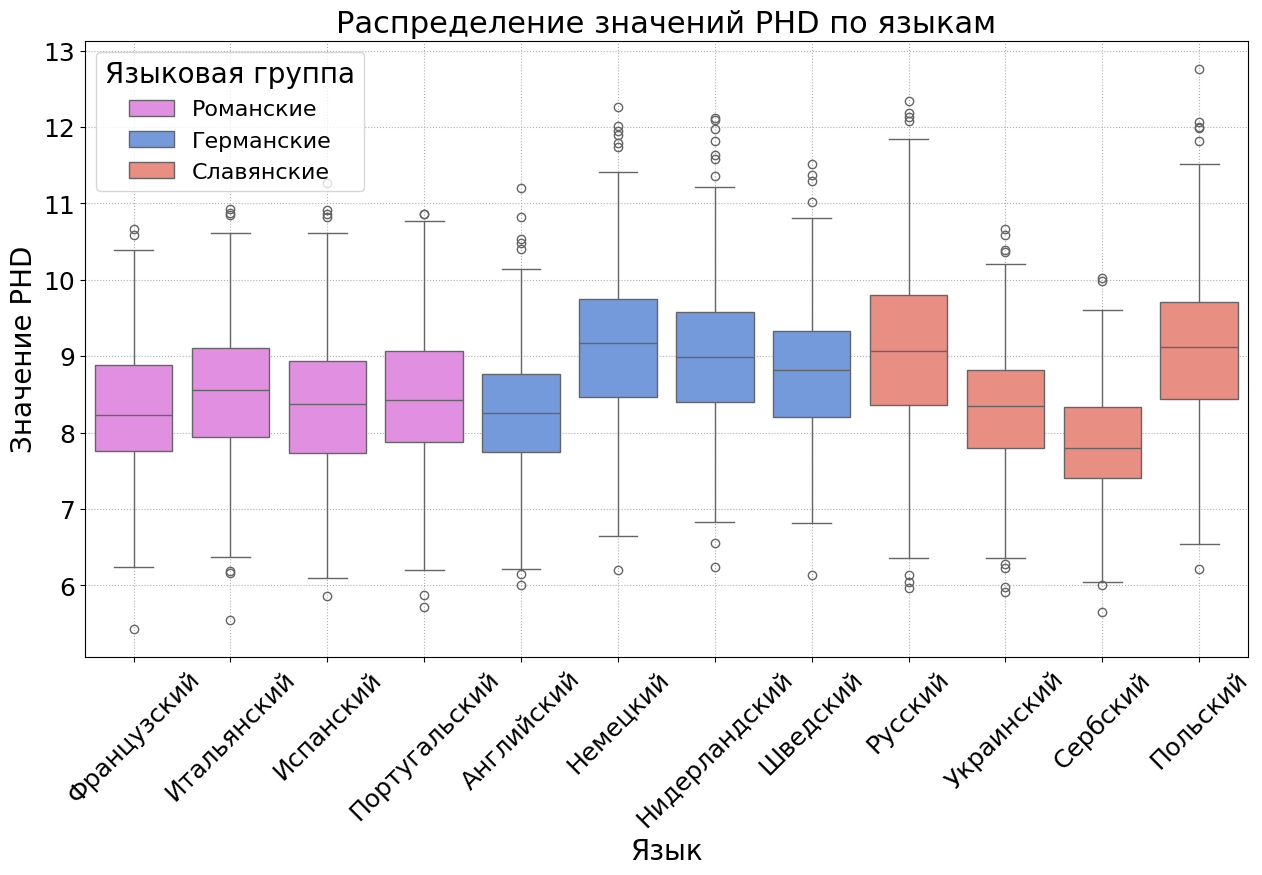

In [80]:
plt.figure(figsize=(15, 8))
sns.boxplot(x="Language", y="PHD", hue="Group", data=df_melted, order=languages_order, palette=group_colors)

plt.xlabel("Язык", fontsize=20)
plt.ylabel("Значение PHD", fontsize=20)
plt.title("Распределение значений PHD по языкам", fontsize=22)

plt.xticks(ticks=range(len(languages_order)), labels=languages_order_ru, rotation=45, fontsize=18)
plt.yticks(fontsize=18)

plt.legend(title="Языковая группа", title_fontsize=20, fontsize=16)

plt.grid(True, ls=":")
plt.savefig("languages_boxplot.png", bbox_inches='tight')
plt.show()

#### Визуализация распределения PHD по языковым группам

In [81]:
df_groups_box = df_groups[["phd_romance", "phd_germanic", "phd_slavic"]].copy()
df_groups_box.columns = ["Романская", "Германская", "Славянская"]

df_melted_groups = df_groups_box.melt(var_name="Group", value_name="PHD")

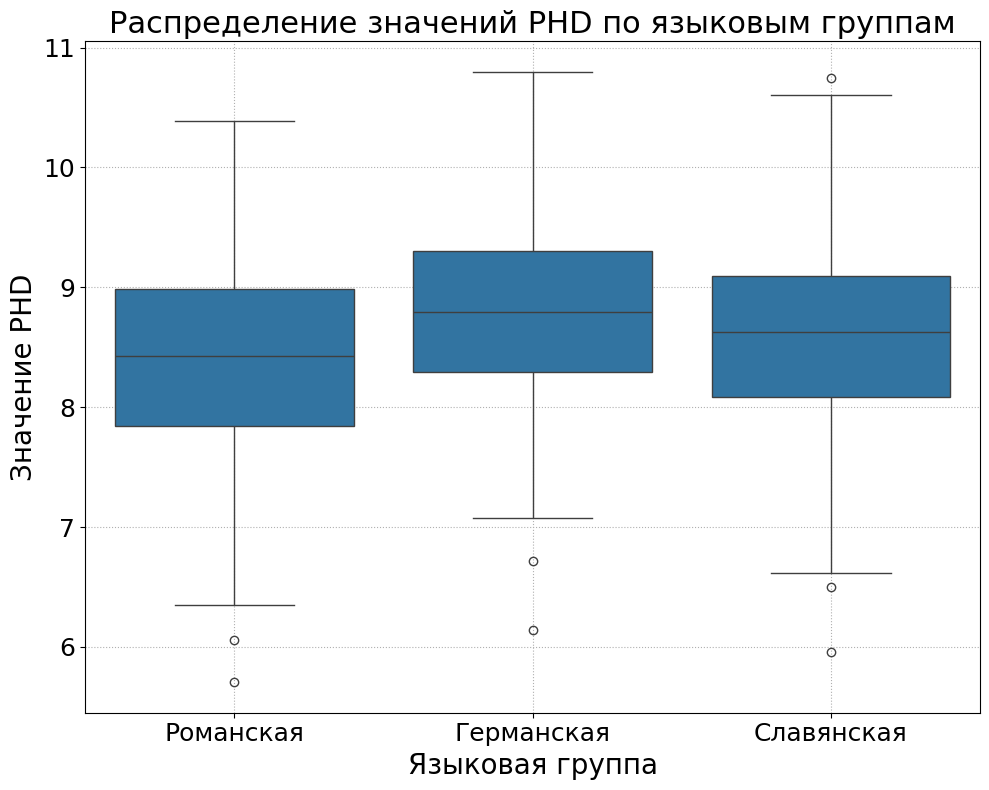

In [82]:
plt.figure(figsize=(10, 8))
sns.boxplot(x="Group", y="PHD", data=df_melted_groups)

plt.xlabel("Языковая группа", fontsize=20)
plt.ylabel("Значение PHD", fontsize=20)
plt.title("Распределение значений PHD по языковым группам", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.grid(True, ls=":")

plt.tight_layout()
plt.savefig("groups_boxplot.png")
plt.show()

### Исследование влияния языка на PHD

#### Влияние непосредственно языка

In [4]:
df_lang = pd.read_csv("phd_languages.csv")

In [5]:
df_long = df_lang.melt(id_vars=['wikidata_id'], var_name='language', value_name='phd')
df_long['language'] = df_long['language'].str.replace('phd_', '')

In [6]:
df_wide = df_lang.set_index('wikidata_id')
df_wide.columns = df_wide.columns.str.replace('phd_', '')

In [7]:
anova_rm = AnovaRM(df_long, depvar='phd', subject='wikidata_id', within=['language'])
results = anova_rm.fit()
print(results)

                  Anova
         F Value   Num DF   Den DF  Pr > F
------------------------------------------
language 286.8877 11.0000 5489.0000 0.0000



Видим, что заивисимость от языка есть: хотя бы для какой-то пары языков есть статистически значимые различия средних значений phd.

Отдельно проверим критерий Фридмана:

In [8]:
stat, p_friedman = friedmanchisquare(*df_wide.values)
print(stat, p_friedman)

3714.0975728542944 0.0


Снова получили, что хотя бы в одной паре стат. значимые различия есть.

In [9]:
posthoc = sp.posthoc_nemenyi_friedman(df_wide)
print(posthoc)

              en            de            nl            sv            fr  \
en  1.000000e+00  2.220446e-16  2.220446e-16  2.220446e-16  9.992575e-01   
de  2.220446e-16  1.000000e+00  5.363449e-02  1.029177e-13  2.220446e-16   
nl  2.220446e-16  5.363449e-02  1.000000e+00  1.438856e-04  2.220446e-16   
sv  2.220446e-16  1.029177e-13  1.438856e-04  1.000000e+00  2.220446e-16   
fr  9.992575e-01  2.220446e-16  2.220446e-16  2.220446e-16  1.000000e+00   
es  9.540889e-01  2.220446e-16  2.220446e-16  2.220446e-16  4.528029e-01   
it  5.732746e-07  2.220446e-16  2.220446e-16  5.329663e-09  2.077829e-09   
pt  2.758022e-03  2.220446e-16  2.220446e-16  1.842970e-14  4.629521e-05   
ru  2.220446e-16  6.694530e-01  9.882988e-01  1.899628e-07  2.220446e-16   
pl  2.220446e-16  9.998592e-01  3.399274e-01  3.259248e-11  2.220446e-16   
uk  8.556789e-01  2.220446e-16  2.220446e-16  2.220446e-16  2.717221e-01   
sr  1.098233e-12  2.220446e-16  2.220446e-16  2.220446e-16  7.476961e-10   

           

In [19]:
k = len(posthoc.columns)
total_pairs = k * (k - 1) // 2
significant_pairs = sum(1 for i in range(k) for j in range(i+1, k) if posthoc.iloc[i, j] < 0.05)

print(f"Всего пар языков: {total_pairs}")
print(f"Статистически значимо различающихся пар: {significant_pairs} ({significant_pairs/total_pairs:.2%})")

Всего пар языков: 66
Статистически значимо различающихся пар: 51 (77.27%)


In [13]:
non_significant_pairs = 0

for i in range(k):
    for j in range(i+1, k):
        p_val = posthoc.iloc[i, j]
        if p_val < 0.05:
            significant_pairs += 1
        else:
            non_significant_pairs += 1
            print(f"{posthoc.index[i]} vs {posthoc.columns[j]}: p = {p_val:.4f}")

en vs fr: p = 0.9993
en vs es: p = 0.9541
en vs uk: p = 0.8557
de vs nl: p = 0.0536
de vs ru: p = 0.6695
de vs pl: p = 0.9999
nl vs ru: p = 0.9883
nl vs pl: p = 0.3399
fr vs es: p = 0.4528
fr vs uk: p = 0.2717
es vs pt: p = 0.2668
es vs uk: p = 1.0000
it vs pt: p = 0.8759
pt vs uk: p = 0.4466
ru vs pl: p = 0.9806


Видим, что в значительном числе пар языков есть стат. значимые различия между phd. Статистически незначимые результаты получили для пар языков из разных языковых групп.

##### Эксперимент с разбиением на независимые выборки

In [30]:
def make_independent_samples(df, categories, category_name='language'):

    n_total = len(df)
    n_cats = len(categories)
    n_per_group = n_total // n_cats
    remainder = n_total % n_cats

    indices = list(range(n_total))
    random.shuffle(indices)

    groups = []
    start = 0
    for i in range(n_cats):
        extra = 1 if i < remainder else 0
        end = start + n_per_group + extra
        groups.append(indices[start:end])
        start = end

    data_long = []
    for idx, cat in enumerate(categories):
        col = f'phd_{cat}'
        vals = df.iloc[groups[idx]][col].values
        for val in vals:
            data_long.append((val, cat))

    df_long = pd.DataFrame(data_long, columns=['phd', category_name])
    return df_long

In [31]:
languages = ['ru', 'en', 'de', 'nl', 'sv', 'fr', 'es', 'it', 'pt', 'pl', 'uk', 'sr']
df_long_indep = make_independent_samples(df_lang, languages)

In [32]:
lm = ols('phd ~ C(language)', data=df_long_indep).fit()
table = sm.stats.anova_lm(lm)
table

,df,sum_sq,mean_sq,F,PR(>F)
C(language),11.0,66.045392,6.004127,9.007027,1.052146e-14
Residual,488.0,325.303104,0.666605,NaN,NaN


In [33]:
mc = MultiComparison(df_long_indep['phd'], df_long_indep['language'])
result = mc.tukeyhsd()
print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    de     en  -0.8291 0.0003 -1.4143  -0.244   True
    de     es  -0.8389 0.0002  -1.424 -0.2537   True
    de     fr   -0.581 0.0536 -1.1661  0.0041  False
    de     it  -0.5005 0.1795 -1.0856  0.0847  False
    de     nl   0.0648    1.0 -0.5203  0.6499  False
    de     pl   -0.034    1.0 -0.6226  0.5547  False
    de     pt  -0.6268 0.0255 -1.2154 -0.0381   True
    de     ru   0.0155    1.0 -0.5696  0.6006  False
    de     sr  -0.9719    0.0 -1.5605 -0.3832   True
    de     sv  -0.1819 0.9972  -0.767  0.4032  False
    de     uk  -0.6587 0.0139 -1.2474   -0.07   True
    en     es  -0.0097    1.0 -0.5948  0.5754  False
    en     fr   0.2482 0.9646 -0.3369  0.8333  False
    en     it   0.3287 0.7922 -0.2564  0.9138  False
    en     nl   0.8939    0.0  0.3088   1.479   True
    en     pl   0.7952 0.0007  0.2065  1.3838 

In [34]:
significant_num = sum(result.reject)
total_comparisons = len(result.reject)

print(f"Всего парных языков: {total_comparisons}")
print(f"Статистически значимых различий: {significant_num}")
print(f"Доля значимых: {significant_num / total_comparisons:.2%}")

Всего парных языков: 66
Статистически значимых различий: 25
Доля значимых: 37.88%


Здесь уже более чем в 2 раза меньше стат. значимых различий в парах языков.

#### Влияние языковой группы

In [20]:
df_groups = pd.read_csv("phd_groups.csv")

In [21]:
df_long_groups = df_groups.melt(id_vars=['wikidata_id'], var_name='group', value_name='phd')
df_long_groups['group'] = df_long_groups['group'].str.replace('phd_', '')

In [22]:
df_wide_groups = df_groups.set_index('wikidata_id')
df_wide_groups.columns = df_wide_groups.columns.str.replace('phd_', '')

In [23]:
anova_rm = AnovaRM(df_long_groups, depvar='phd', subject='wikidata_id', within=['group'])
results = anova_rm.fit()
print(results)

                Anova
      F Value  Num DF  Den DF  Pr > F
-------------------------------------
group 161.7163 2.0000 998.0000 0.0000



Между какими-то двумя языковыми группами тоже есть статистически значимые различия.

In [24]:
stat, p_friedman = friedmanchisquare(*df_wide_groups.values)
print(stat, p_friedman)

1271.3117924151702 6.920425610841849e-69


In [25]:
posthoc = sp.posthoc_nemenyi_friedman(df_wide_groups)
print(posthoc)

               romance      germanic        slavic
romance   1.000000e+00  0.000000e+00  1.687539e-14
germanic  0.000000e+00  1.000000e+00  1.042644e-11
slavic    1.687539e-14  1.042644e-11  1.000000e+00


In [26]:
k = len(posthoc.columns)
total_pairs = k * (k - 1) // 2
significant_pairs = sum(1 for i in range(k) for j in range(i+1, k) if posthoc.iloc[i, j] < 0.05)

print(f"Всего пар языков: {total_pairs}")
print(f"Значимо различающихся пар: {significant_pairs} ({significant_pairs/total_pairs:.2%})")

Всего пар языков: 3
Значимо различающихся пар: 3 (100.00%)


Видим, что между всеми языковыми группами есть стат. значимые различия.

##### Эксперимент с независимыми выборками

In [35]:
groups = ['romance', 'germanic', 'slavic']
df_long_indep_groups = make_independent_samples(df_groups, groups, 'group')

In [36]:
lm = ols('phd ~ C(group)', data=df_long_indep_groups).fit()
table = sm.stats.anova_lm(lm)
table

,df,sum_sq,mean_sq,F,PR(>F)
C(group),2.0,22.316576,11.158288,20.447557,2.925560e-09
Residual,497.0,271.214259,0.545703,NaN,NaN


In [37]:
mc = MultiComparison(df_long_indep_groups['phd'], df_long_indep_groups['group'])
result = mc.tukeyhsd()
print(result)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2 meandiff p-adj   lower   upper  reject
-------------------------------------------------------
germanic romance  -0.5169    0.0  -0.707 -0.3269   True
germanic  slavic  -0.2642 0.0034 -0.4545 -0.0739   True
 romance  slavic   0.2527 0.0054  0.0624  0.4431   True
-------------------------------------------------------


Снова получили статистически значимые различия между всеми тремя языковыми группами.